# 期末專案

組員：M144020007 詹襄秝、M144020062 郭倢圻


## 1.專案動機

近期 Threads 成為大眾分享觀點的重要平台，本專案以《葬送的芙莉蓮》為主題，自行開發 Threads 爬蟲蒐集貼文資料，並比較傳統情感字典分析與大型語言模型分析結果，探討不同分析方法在社群媒體文本理解上的差異。

## 2.Threads 爬蟲

*   自行開發 threads 爬蟲程式
*   以關鍵字 “芙莉蓮” 、“葬送的芙莉蓮” 進行文章爬取
*   記錄文章內文與互動數據，進行後續分析

## 3. 資料集

*   平台：Threads
*   時間：5/26-27、6/1-5、6/14-16
*   文章數量：150篇
*   資料欄位：內文、連結、按讚數、瀏覽數、留言數、轉發數、分享數


In [ ]:
import pandas as pd
import os
import jieba
import jieba.analyse
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import Colormap
%matplotlib inline

from ckiptagger import data_utils, construct_dictionary, WS, POS, NER
import time
import datetime

## 4.利用字典法進行情緒分析

載入資料集

In [ ]:
df = pd.read_csv('fp.csv')
df.head()

,Title,Content,Link,Datetime,View,Like,Reply,Repost,Share
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02 10:30:21,120000,2546,95,116,255
1,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03 11:07:22,586,2546,95,116,254
2,看第一眼：哇 好美！芙莉蓮和費倫好優雅,看第一眼：哇 好美！芙莉蓮和費倫好優雅 \n認真看第二眼：修塔爾克怎麼這麼賣力🤣,https://www.threads.com/@ovo1219uu/post/DZFYWE...,2026-06-02 20:48:29,32000,3353,19,60,406
3,如果你過世當天使了,如果你過世當天使了\n你覺得誰會在你的墳墓前面待最久,https://www.threads.com/@little_things_studios...,2026-06-02 21:00:02,130000,1834,696,58,142
4,小提琴不是應該找阿烏拉🙈,小提琴不是應該找阿烏拉🙈,https://www.threads.com/@ben210412/post/DZG6DZ...,2026-06-03 11:02:16,47,1117,6,37,23


資料前處理:
    清除內文為空值的文章、
    將兩個換行取代為句號、
    清除不重要的字如換行與網址

In [ ]:
clear_df = df.copy()

#去除本次不會用到的欄位
drop_cols = ['View','Like',	'Reply','Repost','Share']
clear_df.drop(drop_cols, axis = 1, inplace = True)

#去除文章內容為空值的筆數
clear_df.dropna(subset = ['Content'], axis=0, how='any', inplace=True)

# 轉換 artDate 只保留日期部分（去掉時間）
clear_df['Datetime'] = pd.to_datetime(clear_df['Datetime']).dt.date

#新增['sentence']欄位，用'。'取代'\n\n'，並移除'\n'
clear_df['sentence'] = clear_df['Content'].str.replace(r'\n\n','。', regex=True)
clear_df['sentence'] = clear_df['sentence'].str.replace(r'\n','，', regex=True)

#移除內文中的網址
clear_df['sentence'] = clear_df['sentence'].replace(r'http\S+', '', regex=True).replace(r'www\S+', '', regex=True)

clear_df.head(10)

,Title,Content,Link,Datetime,sentence
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人，才是戀愛市場優質的稀缺品
1,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。，因為他也有在大學裡教哲學，於是，他說他觀察到，現在...
2,看第一眼：哇 好美！芙莉蓮和費倫好優雅,看第一眼：哇 好美！芙莉蓮和費倫好優雅 \n認真看第二眼：修塔爾克怎麼這麼賣力🤣,https://www.threads.com/@ovo1219uu/post/DZFYWE...,2026-06-02,看第一眼：哇 好美！芙莉蓮和費倫好優雅 ，認真看第二眼：修塔爾克怎麼這麼賣力🤣
3,如果你過世當天使了,如果你過世當天使了\n你覺得誰會在你的墳墓前面待最久,https://www.threads.com/@little_things_studios...,2026-06-02,如果你過世當天使了，你覺得誰會在你的墳墓前面待最久
4,小提琴不是應該找阿烏拉🙈,小提琴不是應該找阿烏拉🙈,https://www.threads.com/@ben210412/post/DZG6DZ...,2026-06-03,小提琴不是應該找阿烏拉🙈
5,敢不敢留言一句會被炎上的話,敢不敢留言一句會被炎上的話,https://www.threads.com/@nn_rou/post/DZCjADJk3PO,2026-06-01,敢不敢留言一句會被炎上的話
6,拜託給個關於德文或德國的超酷知識😭😭,拜託給個關於德文或德國的超酷知識😭😭\n各種方面都行！！！！！！！！！！！\n我需要動力繼續...,https://www.threads.com/@__i.have.questions__/...,2026-05-26,拜託給個關於德文或德國的超酷知識😭😭，各種方面都行！！！！！！！！！！！，我需要動力繼續學德文😭
7,先收,先收\n讀了快一年德文還是完全沒動力,https://www.threads.com/@francelinson/post/DY0...,2026-05-27,先收，讀了快一年德文還是完全沒動力
8,「我再也不想看到你這張臉。」,「我再也不想看到你這張臉。」\n\n這句氣話，成了他們父子之間的最後一句话。\n\n家庭最頂...,https://www.threads.com/@end.y_c/post/DZEZm_ZjQcs,2026-06-02,「我再也不想看到你這張臉。」。這句氣話，成了他們父子之間的最後一句话。。家庭最頂級的悲劇，往...
9,修塔爾克: 「所以我必須帶著滿滿的旅途故事，活著回去見他。」,修塔爾克: 「所以我必須帶著滿滿的旅途故事，活著回去見他。」,https://www.threads.com/@end.y_c/post/DZFt_QziM2r,2026-06-02,修塔爾克: 「所以我必須帶著滿滿的旅途故事，活著回去見他。」


斷句

In [ ]:
clear_df['sentence'] = clear_df['sentence'].str.split("[,，。！!？?;]{1,}")

sent_df = clear_df.explode('sentence').reset_index(drop=True)

sent_df.head(10)

,Title,Content,Link,Datetime,sentence
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,才是戀愛市場優質的稀缺品
2,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,想起昨天聽紀金慶老師講《葬送的芙莉蓮》
3,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,因為他也有在大學裡教哲學
4,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,於是
5,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,他說他觀察到
6,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,現在的大學生是很少看書的
7,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,在他小時候的年代
8,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,看金庸小說或者漫畫
9,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,是要躲著家長偷偷地看的


斷詞

In [ ]:
jieba.set_dictionary('dict.txt')

#去除句子中除了字母、數字、空白字符以外的符號
sent_df['sentence'] = sent_df['sentence'].str.replace(r'[^\w\s]+', '', regex=True).astype(str)

# 把長度小於1的sentence刪掉
sent_df = sent_df[sent_df["sentence"].str.len() > 1]

sent_df.head(10)

,Title,Content,Link,Datetime,sentence
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,才是戀愛市場優質的稀缺品
2,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,想起昨天聽紀金慶老師講葬送的芙莉蓮
3,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,因為他也有在大學裡教哲學
4,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,於是
5,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,他說他觀察到
6,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,現在的大學生是很少看書的
7,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,在他小時候的年代
8,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,看金庸小說或者漫畫
9,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,是要躲著家長偷偷地看的


In [ ]:
word_df = sent_df.assign(word = sent_df['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

# 去除空值
word_df = word_df.dropna(subset=['word'])

word_df.head(10)

Building prefix dict from /Users/guo8/Downloads/SMA_2026S-main/dict.txt ...
Loading model from cache /var/folders/b3/m5n62cbx373fgfgqghmj2hww0000gn/T/jieba.u1e095cd78014f66849fbfce8a3f68751.cache
Loading model cost 0.173 seconds.
Prefix dict has been built successfully.


,Title,Content,Link,Datetime,word
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,喜歡
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,讀書
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,跟
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,看
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,電影
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,的
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,人
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,才
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,是


計算去除停用字及更新字典前的詞頻並視覺化結果

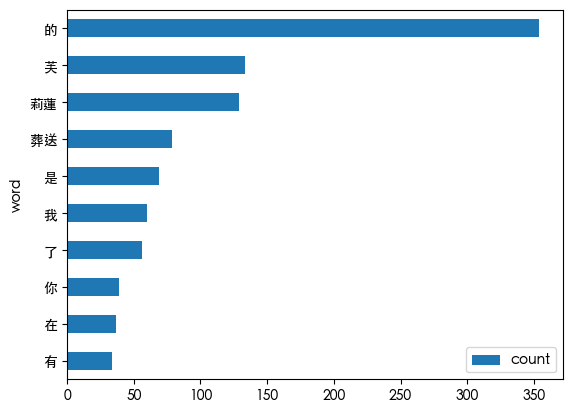

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = ['sans-serif']

plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Microsoft JhengHei', 'Arial']

plt.rcParams['axes.unicode_minus'] = False

word_df = word_df[word_df['word'].str.strip() != '']

freq_df = word_df['word'].value_counts().reset_index()
freq_df.columns = ['word', 'count']
freq_df = freq_df.sort_values(by=['count'], ascending=False)

ax = freq_df.head(10).plot.barh(x='word', y='count')
ax.invert_yaxis()

plt.show()

In [ ]:
# wordcloud的輸入須為dict，因此先將freq_df轉換成成dict
freq_dict = freq_df.set_index('word').to_dict()
freq_dict = freq_dict['count']

print(dict(list(freq_dict.items())[:10]))

{'的': 354, '芙': 133, '莉蓮': 129, '葬送': 79, '是': 69, '我': 60, '了': 56, '你': 39, '在': 37, '有': 34}


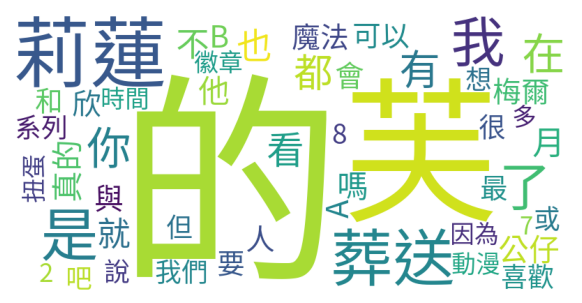

In [ ]:
# 繪製文字雲
wordcloud = WordCloud(background_color = 'white', width = 800, height = 400, font_path = FontPath, max_words = 50)
wordcloud.generate_from_frequencies(freq_dict)

plt.figure(figsize = (6,4))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [ ]:
#去除少於兩個字的詞語
word_df = word_df.loc[word_df['word'].str.len() > 1]

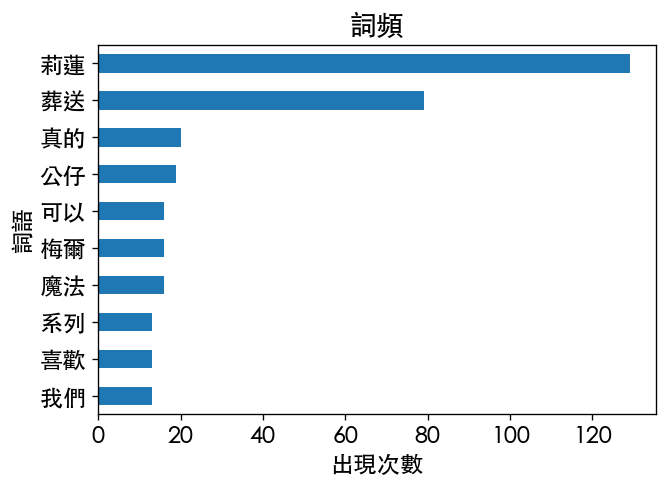

In [ ]:
plt.rcParams['font.family'] = ['sans-serif']

plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Microsoft JhengHei', 'Arial']

plt.rcParams['axes.unicode_minus'] = False
# 產生詞頻 DataFrame
freq_df = word_df['word'].value_counts().reset_index()
freq_df.columns = ['word', 'count']
freq_df = freq_df.sort_values(by=['count'], ascending=False)

# 繪製長條圖
ax = freq_df.head(10).plot.barh(x='word', y='count', legend=False)
ax.invert_yaxis()  # 高first
plt.xlabel("出現次數")
plt.ylabel("詞語")
plt.title("詞頻")
plt.show()

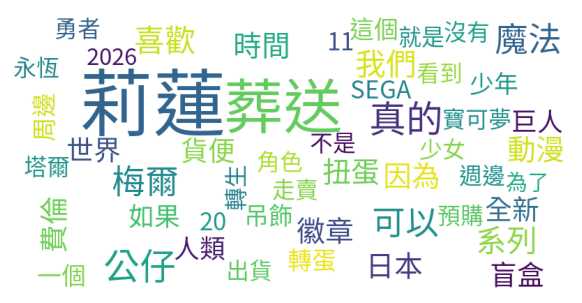

In [ ]:
# wordcloud的輸入須為dict，因此先將freq_df轉換成成dict
freq_dict = freq_df.set_index('word').to_dict()
freq_dict = freq_dict['count']

# 繪製文字雲
wordcloud_no1 = WordCloud(background_color = 'white', width = 800, height = 400, font_path = FontPath, max_words = 50)
wordcloud_no1.generate_from_frequencies(freq_dict)

plt.figure(figsize = (6,4))
plt.imshow(wordcloud_no1)
plt.axis('off')
plt.show()

 移除停用字

In [ ]:
stopwords = [line.strip() for line in open('stopwords.txt', 'r', encoding='utf-8').readlines()]

In [ ]:
noStop_df = word_df[~word_df['word'].isin(stopwords)]

noStop_df.head(10)

,Title,Content,Link,Datetime,word
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,喜歡
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,讀書
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,電影
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,戀愛
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,市場
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,優質
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,稀缺
2,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,想起
2,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,昨天


計算詞頻並繪製長條圖

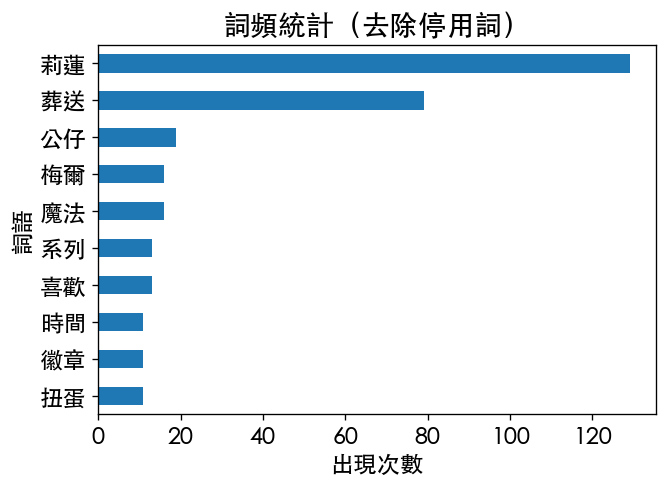

In [ ]:
# 產生詞頻 DataFrame
freq_df_nostop = noStop_df['word'].value_counts().reset_index()
freq_df_nostop.columns = ['word', 'count']  # 設定正確的欄位名稱
freq_df_nostop = freq_df_nostop.sort_values(by=['count'], ascending=False)  # 按次數排序

# 繪製水平長條圖
ax = freq_df_nostop.head(10).plot.barh(x='word', y='count', legend=False)
ax.invert_yaxis()  # 讓最高頻詞排在最上方
plt.xlabel("出現次數")
plt.ylabel("詞語")
plt.title("詞頻統計（去除停用詞）")
plt.show()

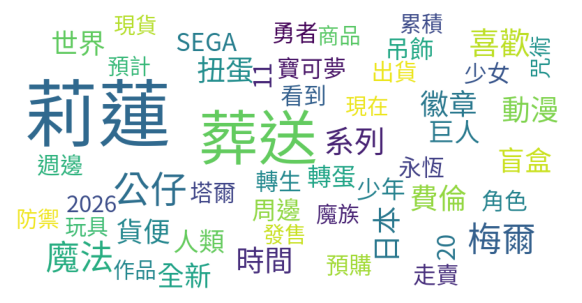

In [ ]:
freq_dict_nostop = freq_df_nostop.set_index('word').to_dict()
freq_dict_nostop = freq_dict_nostop['count']

# 繪製文字雲
wordcloud_nostop = WordCloud(background_color = 'white', width = 800, height = 400, font_path = FontPath, max_words = 50)
wordcloud_nostop.generate_from_frequencies(freq_dict_nostop)

plt.figure(figsize = (6,4))
plt.imshow(wordcloud_nostop)
plt.axis('off')
plt.show()

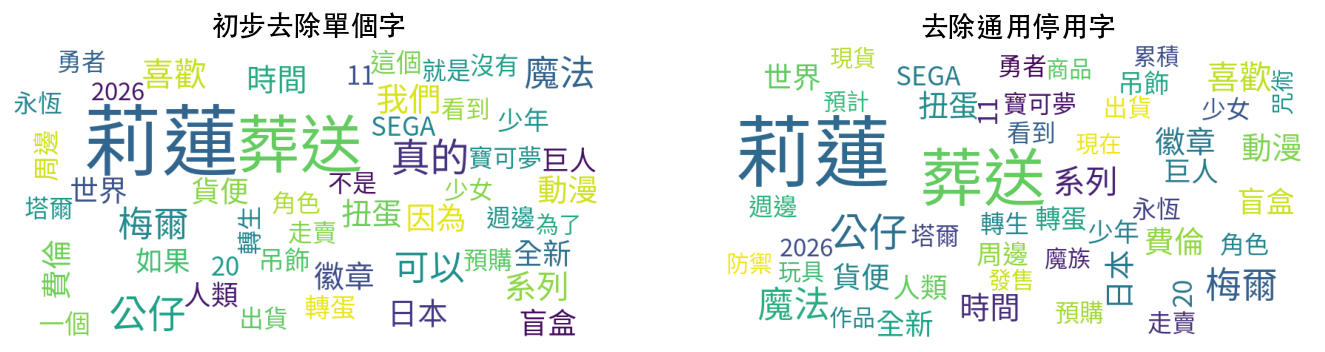

In [ ]:
plt.figure(figsize = (14,8))

plt.subplot(1,2,1)
plt.imshow(wordcloud_no1)
plt.axis('off')
plt.title("初步去除單個字")

plt.subplot(1,2,2)
plt.imshow(wordcloud_nostop)
plt.axis('off')
plt.title("去除通用停用字")

plt.show()

手動更新停用字字典

In [ ]:
stopwords_manual = [
    "一個", "為了", "這個", "就是", "沒有", "可以", "走賣", "系列"]

stopwords.extend(stopwords_manual)

In [ ]:
noStop_df_2 = noStop_df[~noStop_df['word'].isin(stopwords)]
noStop_df_2.head(10)

,Title,Content,Link,Datetime,word
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,喜歡
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,讀書
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,電影
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,戀愛
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,市場
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,優質
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,稀缺
2,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,想起
2,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,昨天


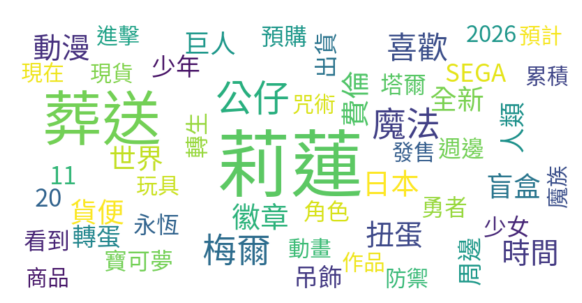

In [ ]:
# 計算詞頻
freq_df_nostop_2 = noStop_df_2['word'].value_counts().reset_index()
freq_df_nostop_2.columns = ['word', 'count']  # 設定正確的欄位名稱
freq_df_nostop_2 = freq_df_nostop_2.sort_values(by=['count'], ascending=False)  # 重新排序

# wordcloud 的輸入須為 dict，因此轉換 freq_df
freq_dict_nostop_2 = freq_df_nostop_2.set_index('word')['count'].to_dict()

# 繪製文字雲
wordcloud_nostop_2 = WordCloud(
    background_color='white',
    width=800,
    height=400,
    font_path=FontPath,
    max_words=50
).generate_from_frequencies(freq_dict_nostop_2)

plt.figure(figsize=(6,4))
plt.imshow(wordcloud_nostop_2, interpolation='bilinear')
plt.axis('off')
plt.show()

比較不同階段文字雲

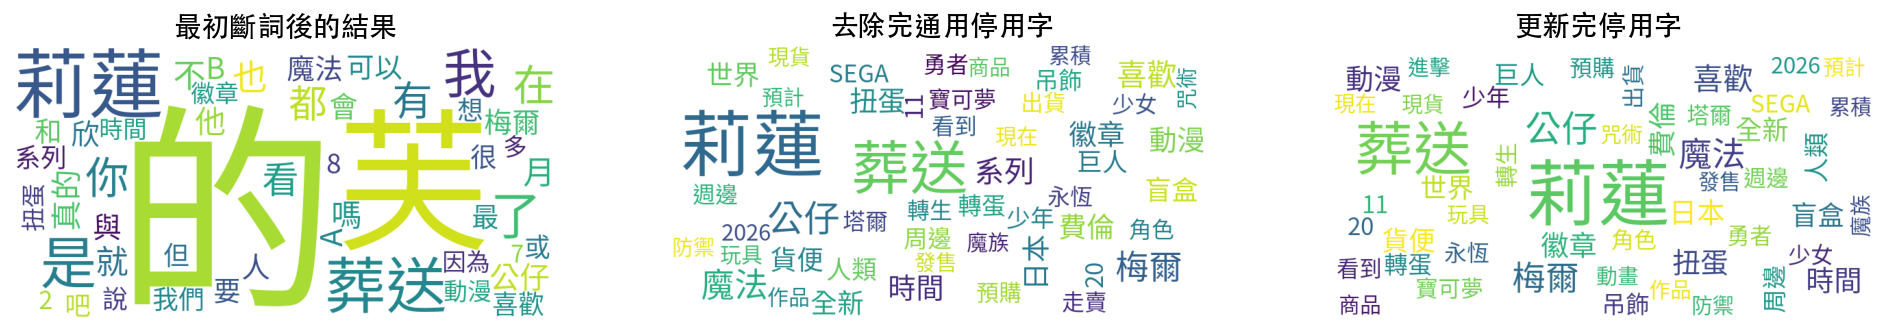

In [ ]:
plt.figure(figsize = (20,14))

plt.subplot(1,3,1)
plt.imshow(wordcloud)
plt.axis('off')
plt.title("最初斷詞後的結果")

plt.subplot(1,3,2)
plt.imshow(wordcloud_nostop)
plt.axis('off')
plt.title("去除完通用停用字")

plt.subplot(1,3,3)
plt.imshow(wordcloud_nostop_2)
plt.axis('off')
plt.title("更新完停用字")

plt.show()

情緒字典與斷詞結果進行合併

準備LIWC字典

In [ ]:
# 讀取情緒字典
liwc_dict = pd.read_csv("LIWC_CH.csv")
liwc_dict = liwc_dict.rename(columns={'name': 'word', "class": 'sentiments'})
liwc_dict.head()

,word,sentiments
0,):,affect
1,3q,affect
2,:(,affect
3,:),affect
4,<3,affect


情緒字典與斷詞結果進行合併

In [ ]:
ptt_liwc_df = pd.merge(noStop_df_2, liwc_dict, how="left")
ptt_liwc_df.head()

,Title,Content,Link,Datetime,word,sentiments
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在,NaN
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,喜歡,affect
2,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,喜歡,positive
3,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,讀書,NaN
4,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,電影,NaN


正負向情緒詞彙頻率折線圖：
分別畫出資料集中，正向（positive）與負向（negative）情緒的折線圖

In [ ]:
sentiment_count = pd.DataFrame(
    ptt_liwc_df.groupby(["Datetime", "sentiments"]).size()
).reset_index()

mask = (sentiment_count['sentiments'] == "positive") | (sentiment_count['sentiments'] == "negative")
sentiment_count = sentiment_count.loc[mask]

sentiment_count = sentiment_count.rename(columns={0: "size"})
sentiment_count = sentiment_count.sort_values(["Datetime"])
sentiment_count.head(10)

,Datetime,sentiments,size
2,2026-06-01,negative,2
7,2026-06-02,negative,8
8,2026-06-02,positive,29
13,2026-06-03,negative,24
14,2026-06-03,positive,31
18,2026-06-04,negative,2
19,2026-06-04,positive,20
22,2026-06-05,negative,11
23,2026-06-05,positive,11
26,2026-06-14,negative,1


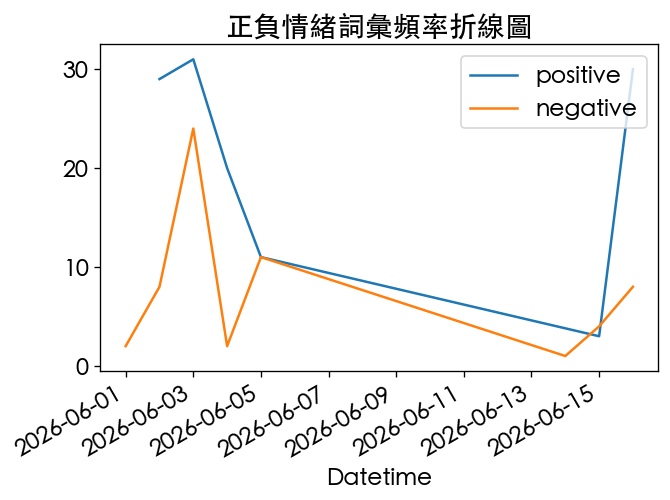

In [ ]:
colors = ["tab:blue", "tab:orange"]
pos = sentiment_count[sentiment_count["sentiments"] == "positive"]
neg = sentiment_count[sentiment_count["sentiments"] == "negative"]

fig, ax = plt.subplots()

ax.plot(pos["Datetime"], pos["size"], color=colors[0])
ax.plot(neg["Datetime"], neg["size"], color=colors[1])

plt.xlabel("Datetime")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負情緒詞彙頻率折線圖")
plt.show()

正負向情緒分數折線圖

In [ ]:
sentiment_count.head(10)

,Datetime,sentiments,size,ratio
2,2026-06-01,negative,2,1.000000
7,2026-06-02,negative,8,0.216216
8,2026-06-02,positive,29,0.783784
13,2026-06-03,negative,24,0.436364
14,2026-06-03,positive,31,0.563636
18,2026-06-04,negative,2,0.090909
19,2026-06-04,positive,20,0.909091
22,2026-06-05,negative,11,0.500000
23,2026-06-05,positive,11,0.500000
26,2026-06-14,negative,1,1.000000


In [ ]:
ptt_sentiment_value = (
    sentiment_count.pivot_table(
        index="Datetime", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
ptt_sentiment_value.head()

,Datetime,negative,positive
0,2026-06-01,2.0,0.0
1,2026-06-02,8.0,29.0
2,2026-06-03,24.0,31.0
3,2026-06-04,2.0,20.0
4,2026-06-05,11.0,11.0


In [ ]:
# sentiment 計算方式: positive - negative
ptt_sentiment_value["sentiment_value"] = (
    ptt_sentiment_value["positive"]
    - ptt_sentiment_value["negative"]
)
ptt_sentiment_value.head()

,Datetime,negative,positive,sentiment_value
0,2026-06-01,2.0,0.0,-2.0
1,2026-06-02,8.0,29.0,21.0
2,2026-06-03,24.0,31.0,7.0
3,2026-06-04,2.0,20.0,18.0
4,2026-06-05,11.0,11.0,0.0


Text(0.5, 1.0, '正負情緒分數趨勢折線圖')

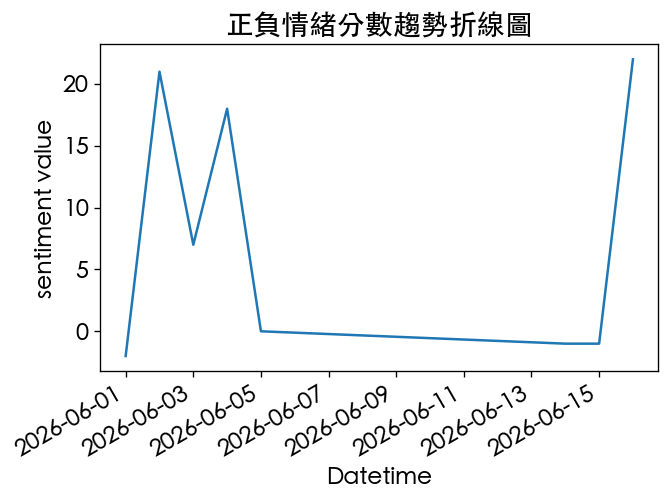

In [ ]:
fig, ax = plt.subplots()

rolling_days = 1
ax.plot(ptt_sentiment_value["Datetime"], ptt_sentiment_value["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("Datetime")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("正負情緒分數趨勢折線圖")

透過結果可看出6/2、6/4、6/16正向情緒分數較高

以文章為單位的情緒分析

In [ ]:
sentiment_count_by_article = pd.DataFrame(
    ptt_liwc_df.groupby(["Link", "sentiments"]).size()
).reset_index()
sentiment_count_by_article = sentiment_count_by_article.rename(columns={0: "size"})
sentiment_count_by_article.head(10)

,Link,sentiments,size
0,https://www.threads.com/@__i.have.questions__/...,affect,1
1,https://www.threads.com/@__roy0831__/post/DZGt...,affect,2
2,https://www.threads.com/@__roy0831__/post/DZGt...,anx,1
3,https://www.threads.com/@__roy0831__/post/DZGt...,negative,1
4,https://www.threads.com/@__roy0831__/post/DZGt...,positive,1
5,https://www.threads.com/@acmo.zi/post/DZLzuJ3mLDb,affect,1
6,https://www.threads.com/@acmo.zi/post/DZLzuJ3mLDb,positive,1
7,https://www.threads.com/@aichoa2025/post/DZKvh...,affect,3
8,https://www.threads.com/@aichoa2025/post/DZKvh...,positive,2
9,https://www.threads.com/@alexia82812/post/DZof...,affect,1


In [ ]:
ptt_sentiment_value_by_article = (
    sentiment_count_by_article.pivot_table(
        index="Link", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
ptt_sentiment_value_by_article.head()

,Link,affect,anger,anx,negative,positive,sad
0,https://www.threads.com/@__i.have.questions__/...,1.0,0.0,0.0,0.0,0.0,0.0
1,https://www.threads.com/@__roy0831__/post/DZGt...,2.0,0.0,1.0,1.0,1.0,0.0
2,https://www.threads.com/@acmo.zi/post/DZLzuJ3mLDb,1.0,0.0,0.0,0.0,1.0,0.0
3,https://www.threads.com/@aichoa2025/post/DZKvh...,3.0,0.0,0.0,0.0,2.0,0.0
4,https://www.threads.com/@alexia82812/post/DZof...,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# sentiment 計算方式: positive - negative
ptt_sentiment_value_by_article["sentiment_value"] = (
    ptt_sentiment_value_by_article["positive"]
    - ptt_sentiment_value_by_article["negative"]
)
ptt_sentiment_value_by_article.head()

,Link,affect,anger,anx,negative,positive,sad,sentiment_value
0,https://www.threads.com/@__i.have.questions__/...,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,https://www.threads.com/@__roy0831__/post/DZGt...,2.0,0.0,1.0,1.0,1.0,0.0,0.0
2,https://www.threads.com/@acmo.zi/post/DZLzuJ3mLDb,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,https://www.threads.com/@aichoa2025/post/DZKvh...,3.0,0.0,0.0,0.0,2.0,0.0,2.0
4,https://www.threads.com/@alexia82812/post/DZof...,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
ptt_sentiment_value_by_article['sentiment_class'] = ptt_sentiment_value_by_article['sentiment_value'].apply(lambda x: "正向" if x > 0 else "負向" )
ptt_sentiment_value_by_article.head(10)

,Link,affect,anger,anx,negative,positive,sad,sentiment_value,sentiment_class
0,https://www.threads.com/@__i.have.questions__/...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,負向
1,https://www.threads.com/@__roy0831__/post/DZGt...,2.0,0.0,1.0,1.0,1.0,0.0,0.0,負向
2,https://www.threads.com/@acmo.zi/post/DZLzuJ3mLDb,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
3,https://www.threads.com/@aichoa2025/post/DZKvh...,3.0,0.0,0.0,0.0,2.0,0.0,2.0,正向
4,https://www.threads.com/@alexia82812/post/DZof...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
5,https://www.threads.com/@anime_supply_station_...,2.0,0.0,0.0,0.0,2.0,0.0,2.0,正向
6,https://www.threads.com/@animeeon_tw/post/DZGu...,2.0,0.0,0.0,0.0,2.0,0.0,2.0,正向
7,https://www.threads.com/@april_write_/post/DZK...,1.0,0.0,0.0,1.0,0.0,0.0,-1.0,負向
8,https://www.threads.com/@astro.eric1997/post/D...,4.0,1.0,0.0,2.0,2.0,0.0,0.0,負向
9,https://www.threads.com/@attachmentforrose/pos...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向


In [ ]:
# 各文章標示情緒
clear_df_sentiment = pd.merge(df, ptt_sentiment_value_by_article[['Link', 'sentiment_class']], how="left")
clear_df_sentiment["Datetime"] = pd.to_datetime(clear_df_sentiment["Datetime"])
clear_df_sentiment['Datetime'] = clear_df_sentiment['Datetime'].dt.date

clear_df_sentiment.head()

,Title,Content,Link,Datetime,View,Like,Reply,Repost,Share,sentiment_class
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,120000,2546,95,116,255,正向
1,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,586,2546,95,116,254,正向
2,看第一眼：哇 好美！芙莉蓮和費倫好優雅,看第一眼：哇 好美！芙莉蓮和費倫好優雅 \n認真看第二眼：修塔爾克怎麼這麼賣力🤣,https://www.threads.com/@ovo1219uu/post/DZFYWE...,2026-06-02,32000,3353,19,60,406,正向
3,如果你過世當天使了,如果你過世當天使了\n你覺得誰會在你的墳墓前面待最久,https://www.threads.com/@little_things_studios...,2026-06-02,130000,1834,696,58,142,NaN
4,小提琴不是應該找阿烏拉🙈,小提琴不是應該找阿烏拉🙈,https://www.threads.com/@ben210412/post/DZG6DZ...,2026-06-03,47,1117,6,37,23,NaN


In [ ]:
# 留下日期、情緒
sentiment_art_count = pd.DataFrame(
    clear_df_sentiment.groupby(["Datetime", "sentiment_class"]).size()
).reset_index()
sentiment_art_count = sentiment_art_count.rename(columns={0: "size"})
sentiment_art_count = sentiment_art_count.sort_values(["Datetime"])
sentiment_art_count

,Datetime,sentiment_class,size
0,2026-05-26,負向,1
1,2026-06-01,負向,1
2,2026-06-02,正向,13
3,2026-06-02,負向,5
4,2026-06-03,正向,8
5,2026-06-03,負向,5
6,2026-06-04,正向,7
7,2026-06-05,正向,5
8,2026-06-05,負向,4
9,2026-06-14,負向,1


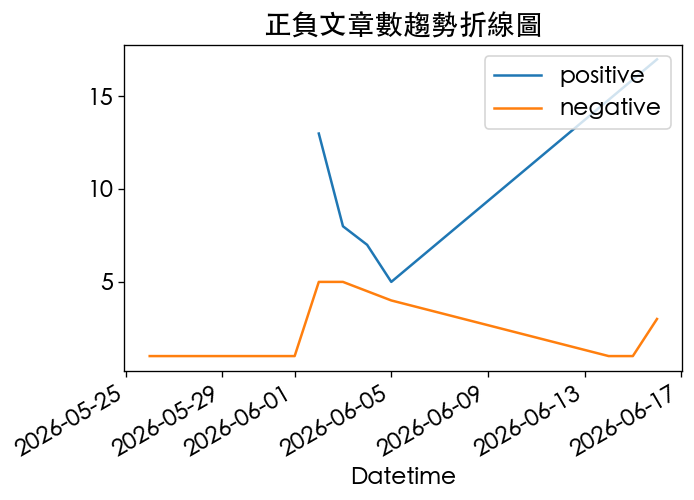

In [ ]:
# 計算14天正負面個別的平均文章數量
colors = ["tab:blue", "tab:orange"]
pos = sentiment_art_count[sentiment_art_count["sentiment_class"] == "正向"]
neg = sentiment_art_count[sentiment_art_count["sentiment_class"] == "負向"]

fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 1
ax.plot(pos["Datetime"], pos['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg["Datetime"], neg["size"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("Datetime")
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("正負文章數趨勢折線圖")
plt.show()

情緒代表字

In [ ]:
# 所有情緒代表字
word_count = ptt_liwc_df.groupby(["word", "sentiments"]).size().reset_index()
word_count = word_count.rename(columns={0: "size"})
word_count = word_count.sort_values(["size"], ascending=False)

word_count.head(10)

,word,sentiments,size
46,喜歡,positive,13
45,喜歡,affect,13
12,作品,affect,6
13,作品,positive,6
154,歡迎,affect,5
38,可愛,positive,5
37,可愛,affect,5
29,冒險,positive,5
28,冒險,affect,5
115,愛情,affect,5


In [ ]:
# 正面情緒代表字
word_of_pos = word_count.loc[(word_count["sentiments"] == "positive")]
word_of_pos.head(15)

,word,sentiments,size
46,喜歡,positive,13
13,作品,positive,6
38,可愛,positive,5
29,冒險,positive,5
116,愛情,positive,5
155,歡迎,positive,5
223,英雄,positive,4
65,好玩,positive,4
164,決心,positive,3
73,完美,positive,3


In [ ]:
# 負面情緒代表字
word_of_neg = word_count.loc[(word_count["sentiments"] == "negative")]
word_of_neg.head(15)

,word,sentiments,size
177,無聊,negative,4
219,背叛,negative,3
142,攻擊,negative,3
99,復仇,negative,2
95,後悔,negative,2
112,惡意,negative,2
204,糟糕,negative,2
160,殘酷,negative,2
249,錯過,negative,2
42,問題,negative,2


/var/folders/b3/m5n62cbx373fgfgqghmj2hww0000gn/T/ipykernel_17072/834213686.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos["word"])
/var/folders/b3/m5n62cbx373fgfgqghmj2hww0000gn/T/ipykernel_17072/834213686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg["word"])


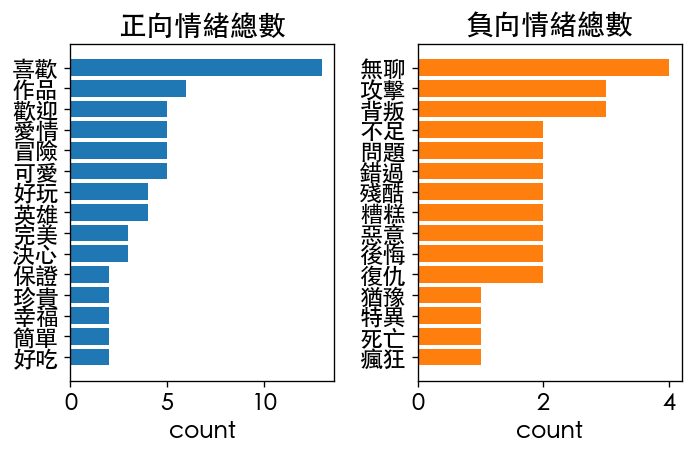

In [ ]:
# 計算正負面個別情緒代表字總數
pos = word_of_pos.head(15).sort_values(["size"], ascending=True)
neg = word_of_neg.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2)

ax[0].barh(pos["word"], pos["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos["word"])
ax[0].set_title("正向情緒總數")

ax[1].barh(neg["word"], neg["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg["word"])
ax[1].set_title("負向情緒總數")

plt.tight_layout()

檢查情緒詞是否符合本文本
『攻擊、瘋狂、復仇』一詞不一定是負面，因此進一步進行分析。

In [ ]:
filtered_df = sent_df[sent_df['sentence'].str.contains('攻擊|瘋狂|復仇')]
filtered_df.head()

,Title,Content,Link,Datetime,sentence
284,夏天的大阪真的會熱到懷疑人生🫠 USJ最新出的「黃昏入場券」根本是救星！下午4點才進場，完美...,夏天的大阪真的會熱到懷疑人生🫠 USJ最新出的「黃昏入場券」根本是救星！下午4點才進場，完美...,https://www.threads.com/@everydayglow_c/post/D...,2026-06-02,夏祭限定今年有超瘋狂的全身濕淋夜間秀和25週年大遊行
525,把基本功練鍛鍊到極致：,把基本功練鍛鍊到極致：\n\n今天去捷運上廁所，看到葬送的芙莉蓮公仔盲盒。\n\n馬上手刀去...,https://www.threads.com/@caiheliang/post/DZK53...,2026-06-05,就只是一般攻擊魔法防禦魔法遮斷氣息
529,把基本功練鍛鍊到極致：,把基本功練鍛鍊到極致：\n\n今天去捷運上廁所，看到葬送的芙莉蓮公仔盲盒。\n\n馬上手刀去...,https://www.threads.com/@caiheliang/post/DZK53...,2026-06-05,也是因為鍛鍊基本工一般攻擊魔法
532,把基本功練鍛鍊到極致：,把基本功練鍛鍊到極致：\n\n今天去捷運上廁所，看到葬送的芙莉蓮公仔盲盒。\n\n馬上手刀去...,https://www.threads.com/@caiheliang/post/DZK53...,2026-06-05,我印象是好像芙莉蓮在戰略上就讓她專心練一般攻擊魔法跟防禦魔法就好
935,以下全屬個人見解,以下全屬個人見解\n不喜就噴\n\n罪惡王冠 D\n進擊的巨人 S\n 刀劍神域 B+\...,https://www.threads.com/@roddy_970904/post/DZm...,2026-06-15,政宗君的復仇 A


In [ ]:
for sentence in filtered_df['sentence'].to_list():
    print(sentence)
    print("=========================")

夏祭限定今年有超瘋狂的全身濕淋夜間秀和25週年大遊行
就只是一般攻擊魔法防禦魔法遮斷氣息
也是因為鍛鍊基本工一般攻擊魔法
我印象是好像芙莉蓮在戰略上就讓她專心練一般攻擊魔法跟防禦魔法就好
政宗君的復仇 A 
Ip 有 獵人轉生史萊姆東京復仇者賽馬娘間諜家家酒藏壽司聯名扭蛋吉伊卡哇路遙一番賞刀劍神域海賊王寶可夢葬送的芙莉蓮進擊的巨人等


In [ ]:
# 設定要移除的字詞列表
words_to_remove = ['攻擊','瘋狂','復仇']
# 使用 ~ 運算子和 isin() 方法過濾掉包含在 words_to_remove 列表中的行
liwc_dict_revise = liwc_dict[~liwc_dict['word'].isin(words_to_remove)]
# 使用更新後的情緒字典 merge
ptt_liwc_df_revise = pd.merge(noStop_df[["Link", "Datetime", "Title", "Content","word"]], liwc_dict_revise, how="left")
ptt_liwc_df_revise.head()

,Link,Datetime,Title,Content,word,sentiments
0,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,現在,NaN
1,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,喜歡,affect
2,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,喜歡,positive
3,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,讀書,NaN
4,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,電影,NaN


/var/folders/b3/m5n62cbx373fgfgqghmj2hww0000gn/T/ipykernel_17072/3563277495.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos["word"])
/var/folders/b3/m5n62cbx373fgfgqghmj2hww0000gn/T/ipykernel_17072/3563277495.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg["word"])


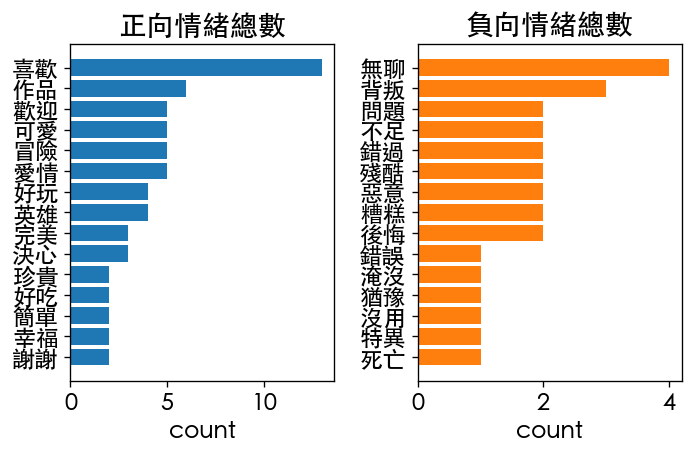

In [ ]:
# 重新計算正負面個別情緒代表字總數
word_count = ptt_liwc_df_revise.groupby(["word", "sentiments"]).size().reset_index()

word_count = word_count.rename(columns={0: "size"})
word_count = word_count.sort_values(["size"], ascending=False)

word_of_pos = word_count.loc[(word_count["sentiments"] == "positive")]
word_of_neg = word_count.loc[(word_count["sentiments"] == "negative")]

pos = word_of_pos.head(15).sort_values(["size"], ascending=True)
neg = word_of_neg.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2)

ax[0].barh(pos["word"], pos["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos["word"])
ax[0].set_title("正向情緒總數")

ax[1].barh(neg["word"], neg["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg["word"])
ax[1].set_title("負向情緒總數")

plt.tight_layout()

文字雲

In [ ]:
# 將前面計算出的文章情緒類別合併，以利過濾出正面文章資料(以詞彙為單位)
ptt_liwc_df_revise = pd.merge(ptt_liwc_df_revise, ptt_sentiment_value_by_article[['Link', 'sentiment_class']], how="left")
ptt_liwc_df_revise.head()

,Link,Datetime,Title,Content,word,sentiments,sentiment_class
0,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,現在,NaN,正向
1,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,喜歡,affect,正向
2,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,喜歡,positive,正向
3,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,讀書,NaN,正向
4,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,電影,NaN,正向


In [ ]:
# 將前面計算出的文章情緒類別合併，以利過濾出正面文章資料(以句子為單位)
sent_df = pd.merge(sent_df, ptt_sentiment_value_by_article[['Link', 'sentiment_class']], how="left")
sent_df.head()

,Title,Content,Link,Datetime,sentence,sentiment_class
0,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,正向
1,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,才是戀愛市場優質的稀缺品,正向
2,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,想起昨天聽紀金慶老師講葬送的芙莉蓮,正向
3,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,因為他也有在大學裡教哲學,正向
4,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。,想起昨天聽紀金慶老師講《葬送的芙莉蓮》。\n因為他也有在大學裡教哲學，於是，他說他觀察到，現...,https://www.threads.com/@francoise0916/post/DZ...,2026-06-03,於是,正向


In [ ]:
# 抓出正面文章
date = "2026-05-01"
end_date = "2026-07-01"
mask = (ptt_liwc_df_revise['Datetime'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['Datetime'] <= pd.Timestamp(end_date).date()) & (
    ptt_liwc_df_revise['sentiment_class'] == "正向")

ptt_df_wc = ptt_liwc_df_revise.loc[mask]
ptt_df_wc.head(10)

,Link,Datetime,Title,Content,word,sentiments,sentiment_class
0,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,現在,NaN,正向
1,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,喜歡,affect,正向
2,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,喜歡,positive,正向
3,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,讀書,NaN,正向
4,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,電影,NaN,正向
5,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,戀愛,affect,正向
6,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,戀愛,positive,正向
7,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,市場,NaN,正向
8,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,優質,NaN,正向
9,https://www.threads.com/@zanyfeng/post/DZERmtg...,2026-06-02,現在喜歡讀書跟看電影的人,現在喜歡讀書跟看電影的人\n才是戀愛市場優質的稀缺品,稀缺,NaN,正向


In [ ]:
# 抓出正面詞彙
date = "2026-05-01"
end_date = "2026-07-01"
mask = (ptt_liwc_df_revise['Datetime'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['Datetime'] <= pd.Timestamp(end_date).date()) & (
    ptt_liwc_df_revise['sentiment_class'] == "正向")

ptt_df_wc = ptt_liwc_df_revise.loc[mask, ["Datetime", "word"]]


word_count_count = pd.DataFrame(
    ptt_df_wc.groupby(["word"]).size()
).reset_index().rename(columns={0: "size"})

word_count_count = word_count_count.sort_values(by='size', ascending=False)
word_count_count.head(10)

,word,size
892,莉蓮,58
896,葬送,41
336,喜歡,24
251,公仔,16
832,系列,11
515,愛情,10
669,歡迎,8
263,冒險,8
952,轉蛋,8
535,扭蛋,8


正向情緒詞彙文字雲

(-0.5, 1599.5, 799.5, -0.5)

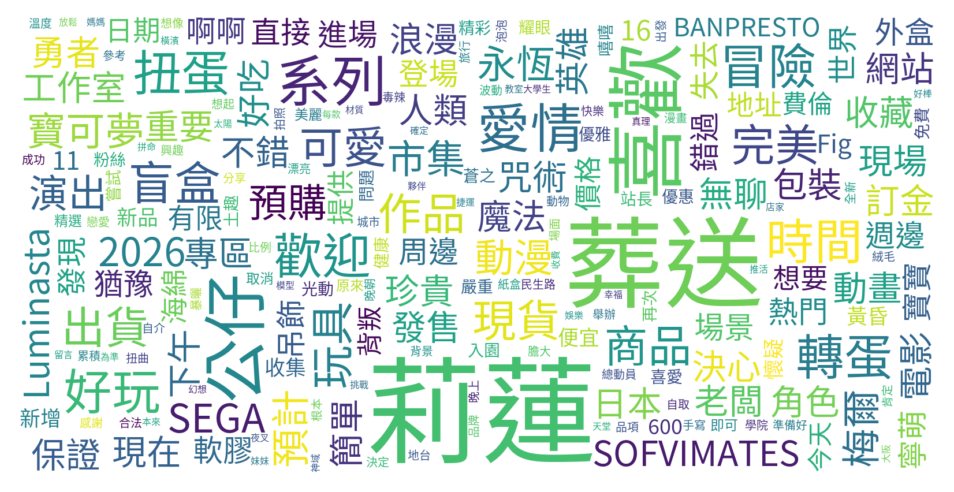

In [ ]:
# 繪製文字雲
# wordcloud 的 input 是 dictionary
font_path = "SourceHanSansTW-Regular.otf"  # 中文字型路徑
wc_dict = dict(zip(word_count_count['word'], word_count_count['size']))
cloud = WordCloud(scale = 4, max_words=200, background_color="white", font_path=font_path)
cloud.generate_from_frequencies(wc_dict)
# 繪圖
plt.figure(figsize=(8, 4), dpi=150)
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
# plt.show()

(-0.5, 1599.5, 799.5, -0.5)

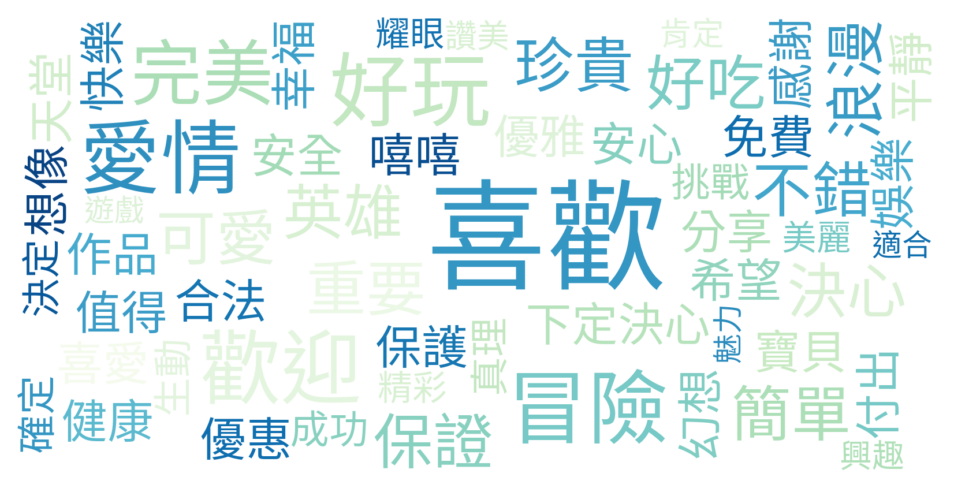

In [ ]:
# 以關鍵字"商務艙"繪製正面文字雲
date = "2026-05-01"
end_date = "2026-07-01"
mask = (ptt_liwc_df_revise['Datetime'] >= pd.Timestamp(date).date()) & (
    ptt_liwc_df_revise['Datetime'] <= pd.Timestamp(end_date).date()) & (
    ptt_liwc_df_revise['sentiment_class'] == "正向")  & (
    ptt_liwc_df_revise['Content'].str.contains('莉蓮')) & (
    ptt_liwc_df_revise["sentiments"] == "positive")

ptt_df_wc = ptt_liwc_df_revise.loc[mask, ["Datetime", "word"]]
wc = ptt_df_wc.groupby(["word"]).size().to_dict()

# wordcloud 的 input 是 dictionary
cloud = WordCloud(scale = 4, max_words=200, background_color="white", font_path=font_path, colormap="GnBu")
cloud.generate_from_frequencies(wc)
# 繪圖
plt.figure(figsize=(8, 4), dpi=150)
plt.imshow(
    cloud,
    interpolation="bilinear"
)
plt.axis("off")
# plt.show()

### 5.LLM分析

In [ ]:
import traceback
import pandas as pd
import json
import time
import re
from openai import OpenAI
from tqdm import tqdm

初始化設定

In [ ]:
client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key="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"
)

df = pd.read_csv('fp.csv')
print("這份檔案的欄位名稱有：", df.columns.tolist())
TEXT_COLUMN = 'Content'
MODEL_NAME = "llama-3.1-8b-instant"

這份檔案的欄位名稱有： ['Title', 'Content', 'Link', 'Datetime', 'View', 'Like', 'Reply', 'Repost', 'Share']


定義LLM分析

In [ ]:
def analyze_sentiment_with_ollama(text):
    if pd.isna(text) or str(text).strip() == "":
        return {"Sentiment": "中性", "Positive_Words": [], "Negative_Words": []}

    prompt = f"""
    你是一個專業的社群媒體情緒分析專家。請分析以下關於動漫「芙莉蓮」的 Threads 貼文。
    請判斷該篇貼文的整體情緒，並萃取出文中有助於判斷情緒的「正面詞彙」與「負面詞彙」。

    請務必只輸出合法的 JSON 格式，不要加入任何解釋或其他文字。
    JSON 格式定義如下：
    {{
        "Sentiment": "正面" 或 "中性" 或 "負面",
        "Positive_Words": ["詞彙1", "詞彙2"],
        "Negative_Words": ["詞彙1", "詞彙2"]
    }}

    貼文內容：
    {text}
    """

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            response_format={ "type": "json_object" }
        )

        result_str = response.choices[0].message.content

        match = re.search(r'\{.*\}', result_str.strip(), re.DOTALL)
        if match:
            clean_json = match.group(0)
            result_dict = json.loads(clean_json)
            return result_dict
        else:
            return json.loads(result_str)

    except Exception as e:
        print(f"\n分析發生錯誤 (內文: {str(text)[:10]}...): {e}")
        traceback.print_exc()
        return {"Sentiment": "Error", "Positive_Words": [], "Negative_Words": []}

執行

In [ ]:
print(f"開始分析")

llm_sentiments = []
llm_pos_words = []
llm_neg_words = []

for text in tqdm(df[TEXT_COLUMN]):
    result = analyze_sentiment_with_ollama(text)

    llm_sentiments.append(result.get('Sentiment', '中性'))
    llm_pos_words.append(", ".join(result.get('Positive_Words', [])))
    llm_neg_words.append(", ".join(result.get('Negative_Words', [])))

df['LLM_Sentiment'] = llm_sentiments
df['LLM_Positive_Words'] = llm_pos_words
df['LLM_Negative_Words'] = llm_neg_words

print("\n分析完成")
display(df[['LLM_Sentiment', 'LLM_Positive_Words', 'LLM_Negative_Words']].head())

df.to_csv('fp_ollama_analyzed.csv', index=False, encoding='utf-8-sig')
print("結果成功儲存")

開始使用 Ollama (llama-3.1-8b-instant) 分析


100%|██████████| 149/149 [08:00<00:00,  3.22s/it]


分析完成


,LLM_Sentiment,LLM_Positive_Words,LLM_Negative_Words
0,負面,,"稀缺品, 戀愛市場"
1,負面,,"失去了, 不是一件好事"
2,正面,"哇, 好美, 優雅",
3,負面,,"過世, 墳墓"
4,負面,,"不是, 應該, 找"


結果成功儲存


視覺化

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang HK', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

FontPath = '/System/Library/Fonts/Supplemental/Songti.ttc'

In [ ]:
df = pd.read_csv('fp_ollama_analyzed.csv')


情緒分析分布圖（圓餅圖）

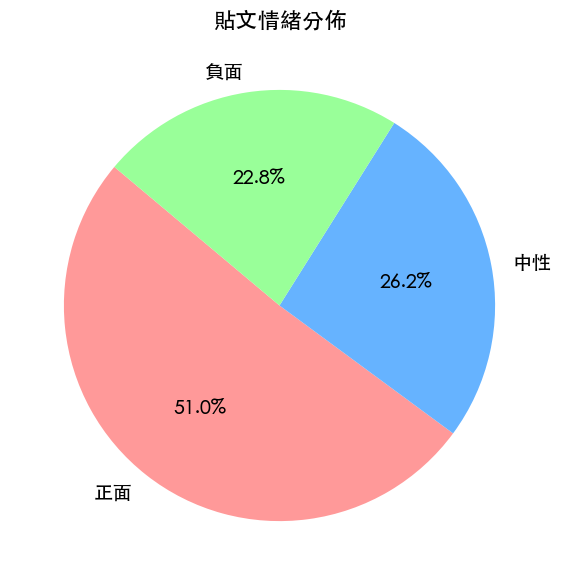

In [ ]:
sentiment_counts = df['LLM_Sentiment'].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        textprops={'fontsize': 14})
plt.title('貼文情緒分佈', fontsize=16, fontweight='bold')
plt.show()

整理正面與負面詞彙頻率

In [ ]:
def get_word_freq(column_data):
    all_words = []

    for text in column_data.dropna():
        if str(text).strip() != "":
            words = [w.strip() for w in str(text).split(',') if w.strip() != ""]
            all_words.extend(words)
    return Counter(all_words)

pos_freq = get_word_freq(df['LLM_Positive_Words'])
neg_freq = get_word_freq(df['LLM_Negative_Words'])

繪製正面詞彙文字雲

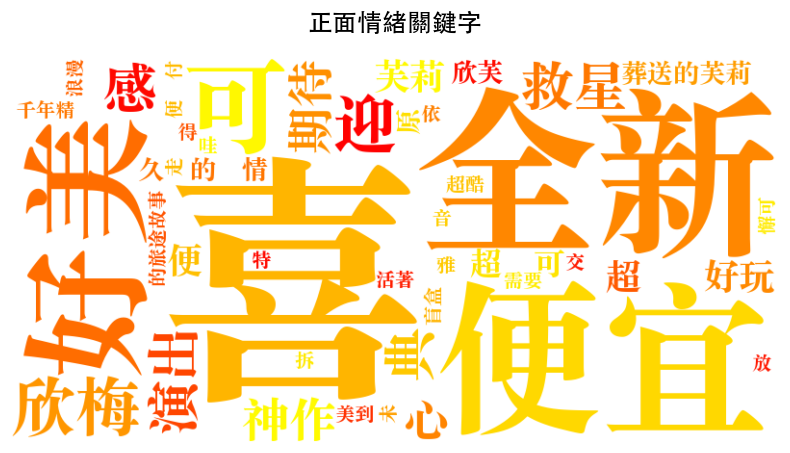

In [ ]:
if pos_freq:
    wc_pos = WordCloud(
        font_path=FontPath,
        background_color='white',
        width=800,
        height=400,
        colormap='autumn',
        max_words=50
    ).generate_from_frequencies(pos_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc_pos, interpolation='bilinear')
    plt.axis('off')
    plt.title('正面情緒關鍵字', fontsize=18, fontweight='bold', pad=20)
    plt.show()
else:
    print("沒有資料")

繪製負面詞彙文字雲

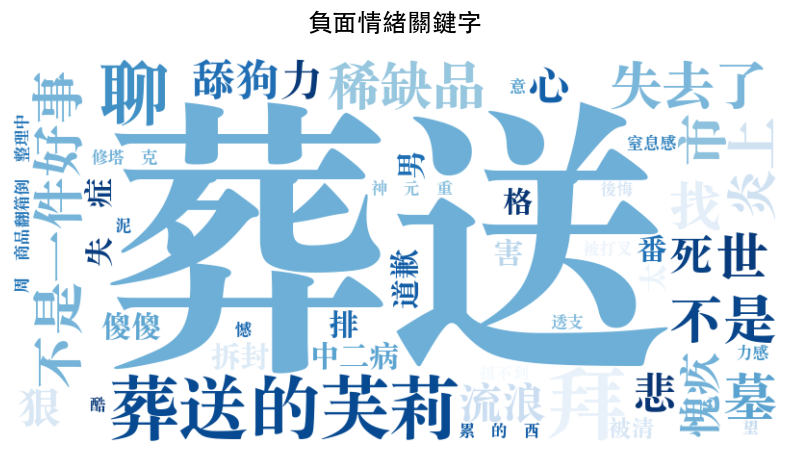

In [ ]:
if neg_freq:
    wc_neg = WordCloud(
        font_path=FontPath,
        background_color='white',
        width=800,
        height=400,
        colormap='Blues',
        max_words=50
    ).generate_from_frequencies(neg_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc_neg, interpolation='bilinear')
    plt.axis('off')
    plt.title('負面情緒關鍵字', fontsize=18, fontweight='bold', color='black', pad=20)
    plt.show()
else:
    print("沒有資料")

折線圖前處理

In [ ]:
df['Date'] = pd.to_datetime(df['Datetime']).dt.date

sentiment_mapping = {
    '正面': 1,
    '中性': 0,
    '負面': -1,
    'Error': 0
}

df['LLM_Score'] = df['LLM_Sentiment'].map(sentiment_mapping)

daily_sentiment = df.groupby('Date')['LLM_Score'].sum().reset_index()

繪製折線圖

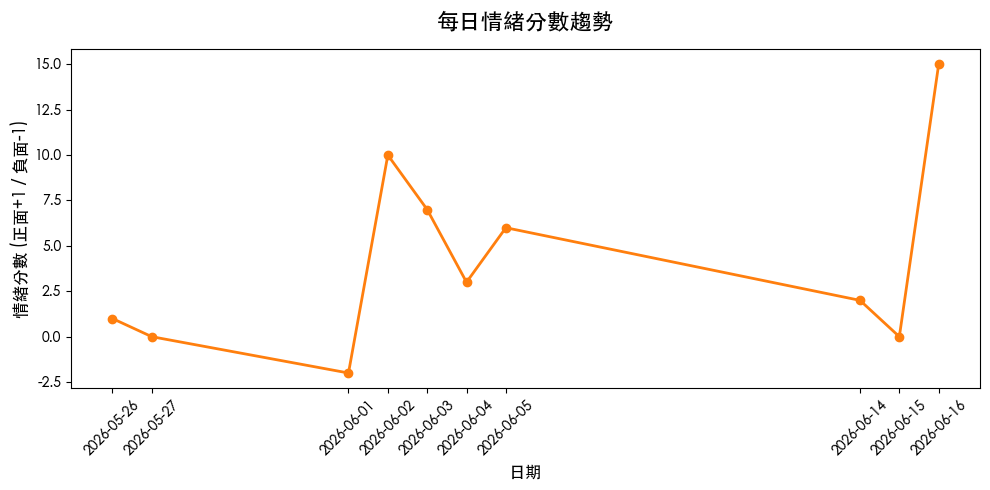

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(daily_sentiment['Date'], daily_sentiment['LLM_Score'],
         color='#ff7f0e', # 使用橘色系，以利與你原本藍色的字典法圖表作區分
         marker='o',
         linestyle='-',
         linewidth=2,
         markersize=6)

plt.title('每日情緒分數趨勢', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('日期', fontsize=12)
plt.ylabel('情緒分數 (正面+1 / 負面-1)', fontsize=12)

plt.xticks(daily_sentiment['Date'], rotation=45)

#plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

由此張折線圖可看出結果與字典法一致，在6/2、6/4、6/16時正向情緒分數較高

## 6.情緒分析結論


*   字典法：
傳統字典法易受到「字面意思」干擾。例如，動漫名稱中的 葬送 二字在字典中通常被歸類為強烈「負向/悲傷」詞彙，但在此情境使用時只是純粹提及作品名稱，可能導致情緒分數產生偏誤。

*   LLM分析：
引入 LLM 讀取整篇貼文的上下文，克服了字典法的痛點，能進行更精準的語意判斷與詞彙提取。




## 7.社會網路圖

In [ ]:
import networkx as nx
import matplotlib.patches as mpatches
import re

文字設定、取得資料

In [ ]:
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang HK', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('fp_ollama_analyzed.csv')

stop_words = {'nan', 'none', 'null', '沒有', '什麼'}

def clean_and_remove_emoji(word):
    cleaned = re.sub(r'[^\w\u4e00-\u9fff]', '', str(word))
    return cleaned.strip()

建立「貼文、詞彙」的 Bipartite Network

In [ ]:
G = nx.Graph()

for index, row in df.iterrows():
    post_node = f"貼文 {index + 1}"
    has_valid_words = False

    # 處理正面詞彙
    pos_words = str(row.get('LLM_Positive_Words', '')).split(',')
    for w in pos_words:
        clean_w = clean_and_remove_emoji(w)

        if clean_w and clean_w.lower() not in stop_words:
            G.add_node(clean_w, node_type='word', polarity='positive')
            G.add_edge(post_node, clean_w)
            has_valid_words = True

    # 處理負面詞彙
    neg_words = str(row.get('LLM_Negative_Words', '')).split(',')
    for w in neg_words:
        clean_w = clean_and_remove_emoji(w)

        if clean_w and clean_w.lower() not in stop_words:
            G.add_node(clean_w, node_type='word', polarity='negative')
            G.add_edge(post_node, clean_w)
            has_valid_words = True

    if has_valid_words:
        G.add_node(post_node, node_type='post')

移除出現次數小於 1 的詞彙

In [ ]:
nodes_to_remove = []

for node, degree in dict(G.degree()).items():
    if G.nodes[node].get('node_type') == 'word' and degree < 2:
        nodes_to_remove.append(node)

G.remove_nodes_from(nodes_to_remove)
G.remove_nodes_from(list(nx.isolates(G)))

視覺化


*   藍色為正面詞彙
*   紅色為負面詞彙



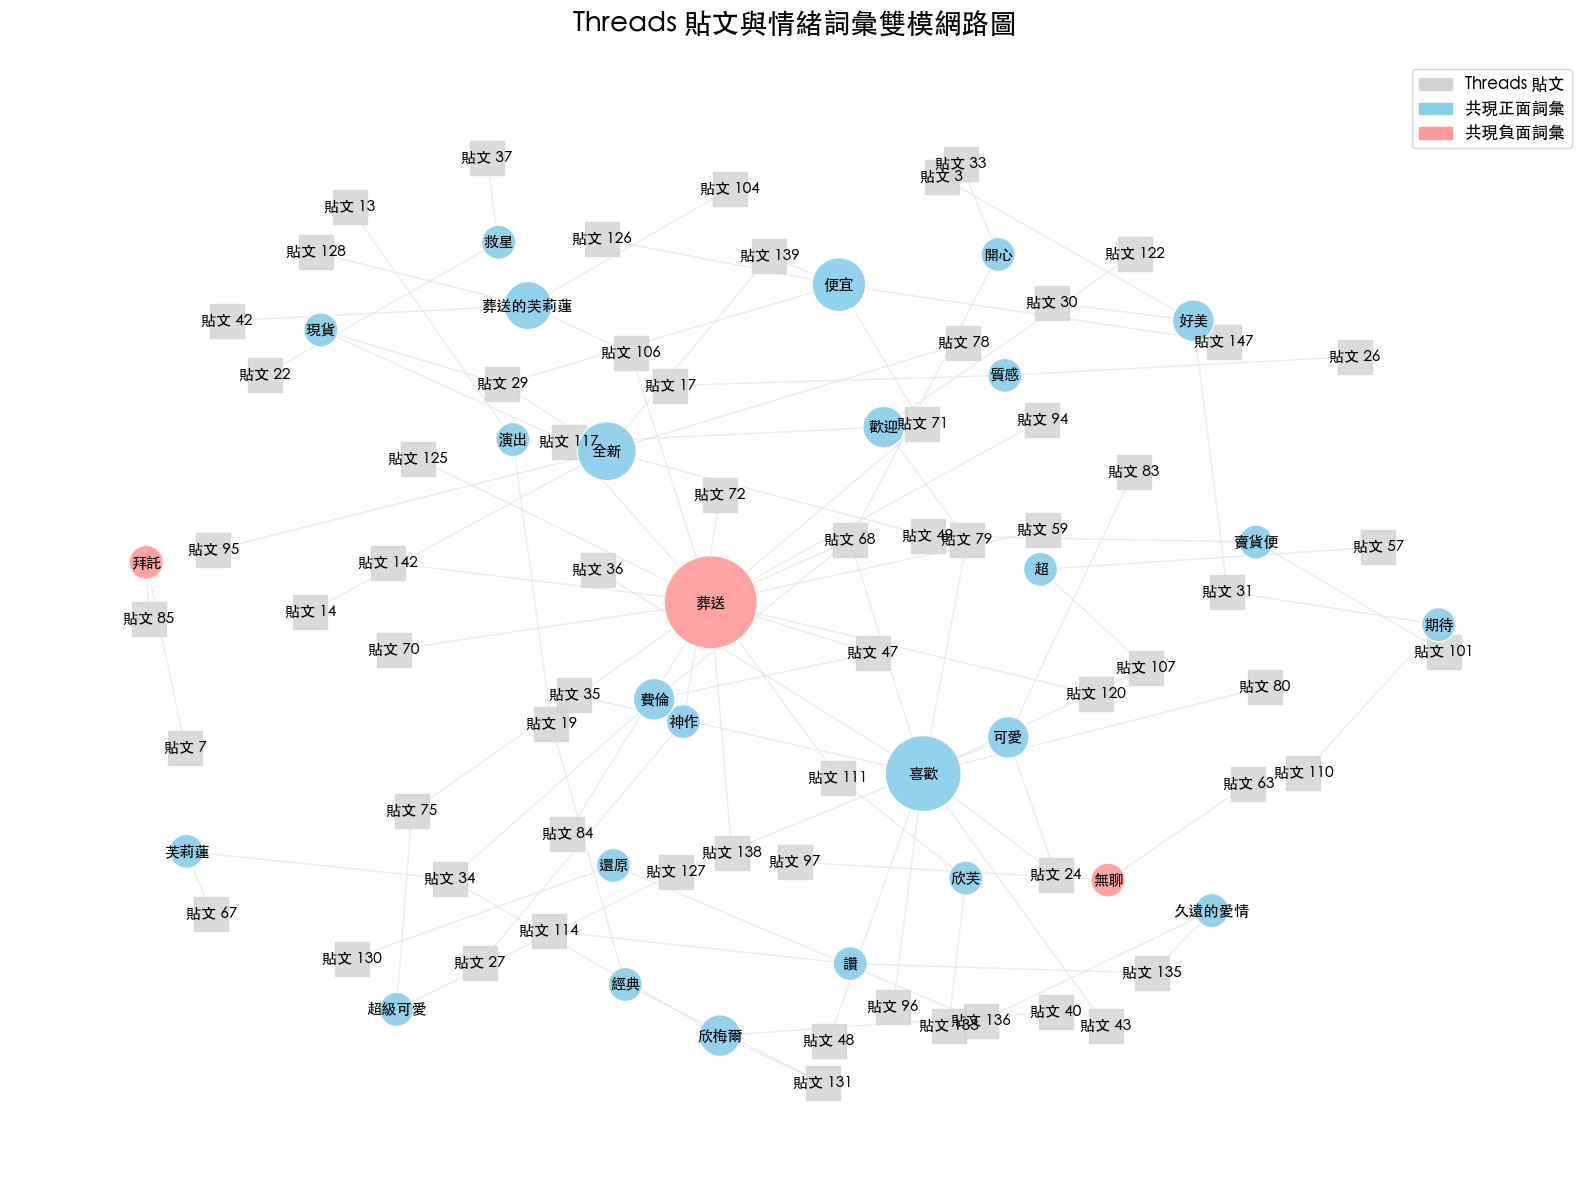

In [ ]:
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

post_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'post']
pos_word_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'word' and d.get('polarity') == 'positive']
neg_word_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'word' and d.get('polarity') == 'negative']

nx.draw_networkx_nodes(G, pos, nodelist=post_nodes, node_color='#D3D3D3', node_shape='s', node_size=600, alpha=0.8)
nx.draw_networkx_nodes(G, pos, nodelist=pos_word_nodes, node_color='#87CEEB', node_size=[G.degree(n)*300 for n in pos_word_nodes], alpha=0.9, edgecolors='white')
nx.draw_networkx_nodes(G, pos, nodelist=neg_word_nodes, node_color='#FF9999', node_size=[G.degree(n)*300 for n in neg_word_nodes], alpha=0.9, edgecolors='white')

nx.draw_networkx_edges(G, pos, edge_color='#E0E0E0', alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=11, font_family='Heiti TC', font_weight='bold')

legend_elements = [
    mpatches.Patch(color='#D3D3D3', label='Threads 貼文'),
    mpatches.Patch(color='#87CEEB', label='共現正面詞彙'),
    mpatches.Patch(color='#FF9999', label='共現負面詞彙')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.title('Threads 貼文與情緒詞彙雙模網路圖', fontsize=20, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

## 8.社會網路圖結論

在剔除雜訊（如空值 nan、表情符號）並過濾掉只出現一次的詞彙後，利用 LLM 提取的情緒核心詞彙與貼文建構出「雙模網路圖」。透過中心度分數，找出了社群網絡中的核心情感節點。



*   周邊商品（全新/便宜）：
在正面情感詞中擁有極高的中心度分數，這顯示在 Threads 的《葬送的芙莉蓮》相關貼文中，「公仔、周邊商品的買賣、交換、出清」是維繫社群高頻互動重要主題。



*   作品描述（好美/演出/經典/可愛/喜歡）：這些內容顯示除了商業買賣外，網友對這部作品的凝聚力來自於「精細的演出、經典的場景、以及角色的可愛互動」。




